In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import pickle
from pathlib import Path

In [74]:
PROC_DIR = Path("data/processed")
FIG_DIR = PROC_DIR / "figures"

# load cleaned data with engineered features
scada = pd.read_csv(PROC_DIR / "scada_features.csv")

In [75]:
# features and target
features = ["wind_speed_ms", "dir_sin", "dir_cos", "wind_power_density"]
target = "active_power_kw"

In [76]:
X = scada[features]
y = scada[target]

In [77]:
# splitting the dataset in a 80/20 ratio. So 80% will be used to train and 20% to test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
# train
model = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_estimators=50, random_state=42)

In [79]:
# evaluate
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

print("Train R^2:", round(r2_score(y_train, y_train_pred), 3))
print("Test R^2:", round(r2_score(y_test, y_pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))

Train R^2: 0.972
Test R^2: 0.905
RMSE: 402.838


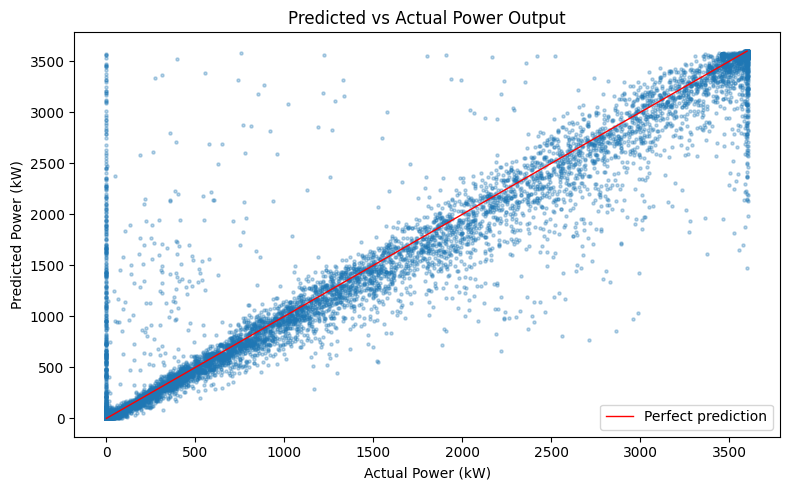

In [80]:
# plot predicted vs actual
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, y_pred, s=5, alpha=0.3)
ax.plot([0, 3600], [0, 3600], color="red", linewidth=1, label="Perfect prediction")
ax.set_xlabel("Actual Power (kW)")
ax.set_ylabel("Predicted Power (kW)")
ax.set_title("Predicted vs Actual Power Output")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "predicted_vs_actual.png", dpi=120)
plt.show()

In [81]:
# export model
with open(PROC_DIR / "model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved to", PROC_DIR / "model.pkl")

Model saved to data/processed/model.pkl
